# Agentic Mobility Model - Complete Showcase

This notebook demonstrates the complete agentic mobility pipeline:
- **Natural Language → Mobility Simulation**: Convert text queries to UE mobility data
- **Topology Generation**: LLM-generated cell tower placement
- **Static & Interactive Visualizations**: Comprehensive analysis tools
- **Location Validation**: Reverse geocoding to verify spatial bounds

---

## Part 0: Environment Setup Instructions

### Step 1: Create Virtual Environment

```bash
# Navigate to project root
cd /path/to/maveric

python3 -m venv venv # python v3.10.16 recommened

source venv/bin/activate
```

### Step 2: Install Requirements

```bash
pip install -r radp/digital_twin/requirements.txt

pip install -r notebooks/requirements.txt

pip install -r requirements-dev.txt
```

### Step 3: Configure API Key

Set your LLM API key:

```bash
# Copy example environment file
cp radp/digital_twin/agentic_mobility/.env.example .env

# Edit the .env file and add your API key and model
```

**Get Groq API Key:** https://console.groq.com/ (free tier available)

---

## Part 1: Introduction & Setup

### What is Agentic Mobility?

Agentic Mobility transforms RADP's mobility generator from **parameter-driven JSON** to **natural language queries** using LLM-powered workflows.

**Key Features:**
- **Natural Language Parsing**: "Generate 100 UEs in Tokyo" → valid parameters
- **Auto-Geocoding**: Location names → lat/lon bounds (cached)
- **Context-Aware**: LLM infers distributions from context (e.g., "rush hour" → high car %)
- **Self-Correction**: Auto-validates + retries with LLM suggestions
- **Parallel Execution**: Location + parameter generation run simultaneously
- **End-to-End**: Complete NL → DataFrame pipeline

### What This Notebook Demonstrates:

1. Natural language → mobility simulation
2. Cell tower topology generation
3. Static matplotlib visualizations
4. Scenario comparison
5. Location validation with reverse geocoding
6. Geographic world map visualization
7. Interactive Plotly dashboards
8. Export to CSV, JSON, PNG, HTML

---

In [1]:
# Setup Python path
import sys
from pathlib import Path

# Add maveric root to path
notebook_dir = Path.cwd()
maveric_root = notebook_dir.parent
if str(maveric_root) not in sys.path:
    sys.path.insert(0, str(maveric_root))

print(f"Notebook directory: {notebook_dir}")
print(f"Maveric root: {maveric_root}")

Notebook directory: /Users/azanzaman/Desktop/maveric1/notebooks
Maveric root: /Users/azanzaman/Desktop/maveric1


In [2]:
# Create output directory
output_dir = Path("data/agentic_data/mobility")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory created: {output_dir}")
print(f"  Absolute path: {output_dir.resolve()}")
print(f"  Directory exists: {output_dir.exists()}")

Output directory created: data/agentic_data/mobility
  Absolute path: /Users/azanzaman/Desktop/maveric1/notebooks/data/agentic_data/mobility
  Directory exists: True


In [3]:
# Import required modules
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from radp.digital_twin.agentic_mobility.integration import AgenticMobilityIntegration
from radp.digital_twin.agentic_mobility.topology_generator import TopologyGenerator
from radp.digital_twin.agentic_mobility.visualization import (
    plot_ue_tracks,
    plot_ue_tracks_comparison,
    plot_ue_tracks_with_topology,
    plot_ue_wise_interactive,
    plot_tick_wise_interactive,
    validate_location_bounds,
    plot_bounds_on_map,
)

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

print("All imports successful!")

All imports successful!


---
## Part 2: Natural Language → Mobility Generation

This section demonstrates the complete pipeline from natural language query to mobility DataFrame.

The system will:
1. Parse the natural language query
2. Resolve the location to lat/lon bounds
3. Generate RADP-compatible parameters
4. Validate and self-correct if needed
5. Generate mobility simulation data

**Note**: First run may take ~5-10 seconds due to LLM API calls and geocoding.

---

In [4]:
# Define natural language query
query = """Give me UE dataset for Toshima, Tokyo, Japan. consider it as a urban area with lots of pedestrians and cars. "
        There are so many motorbikes, consider them as cyclists. Have thirty total devices.
        Deploy 5 cell towers."""

print(f"Query: '{query}'")
print("\nProcessing...")
print("This may take 5-10 seconds (LLM + geocoding API calls)")

Query: 'Give me UE dataset for Toshima, Tokyo, Japan. consider it as a urban area with lots of pedestrians and cars. "
        There are so many motorbikes, consider them as cyclists. Have thirty total devices.
        Deploy 5 cell towers.'

Processing...
This may take 5-10 seconds (LLM + geocoding API calls)


In [5]:
# Generate mobility data from natural language
df, metadata = AgenticMobilityIntegration.generate_from_natural_language(query)

print(f"\nGenerated {len(df)} mobility points for {metadata['query_intent']['num_ues']} UEs")


Generated 1500 mobility points for 30 UEs


In [6]:
# Display key metadata
query_intent = metadata['query_intent']

print("="*70)
print("GENERATION METADATA")
print("="*70)
print(f"Location: {query_intent['location']}")
print(f"Scenario Type: {query_intent['scenario_type']}")
print(f"Number of UEs: {query_intent['num_ues']}")
print(f"Number of Ticks: {query_intent['num_ticks']}")
print(f"Retry Count: {metadata['retry_count']}")
print(f"\nUE Distribution (Source: {query_intent['ue_distribution']['source']}):")
for ue_type, percentage in query_intent['ue_distribution'].items():
    if ue_type == 'source':
        continue
    print(f"  - {ue_type}: {percentage*100:.1f}%")
print("="*70)

GENERATION METADATA
Location: Toshima, Tokyo, Japan
Scenario Type: urban
Number of UEs: 30
Number of Ticks: 50
Retry Count: 0

UE Distribution (Source: predicted):
  - stationary: 6.0%
  - pedestrian: 38.0%
  - cyclist: 18.0%
  - car: 38.0%


In [7]:
# Display DataFrame preview
print("\nDataFrame Preview:")
display(df.head(10))

print(f"\nDataFrame Info:")
print(f"  - Total rows: {len(df)}")
print(f"  - Columns: {list(df.columns)}")
print(f"  - Unique UEs: {df['mock_ue_id'].nunique()}")
print(f"  - Ticks: {df['tick'].min()} to {df['tick'].max()}")
print(f"  - Lat range: [{df['lat'].min():.6f}, {df['lat'].max():.6f}]")
print(f"  - Lon range: [{df['lon'].min():.6f}, {df['lon'].max():.6f}]")


DataFrame Preview:


,mock_ue_id,lon,lat,tick
0,0,139.735325,35.731790,0
1,1,139.713429,35.749787,0
2,2,139.684971,35.740725,0
3,3,139.706481,35.717469,0
4,4,139.755841,35.754207,0
5,5,139.687102,35.695917,0
6,6,139.667616,35.682923,0
7,7,139.692366,35.688972,0
8,8,139.693723,35.745953,0
9,9,139.734618,35.722485,0



DataFrame Info:
  - Total rows: 1500
  - Columns: ['mock_ue_id', 'lon', 'lat', 'tick']
  - Unique UEs: 30
  - Ticks: 0 to 49
  - Lat range: [35.680927, 35.766367]
  - Lon range: [139.661419, 139.767596]


In [8]:
# Save mobility data
csv_path = output_dir / "ue_tracks.csv"
metadata_path = output_dir / "ue_tracks_metadata.json"

df.to_csv(csv_path, index=False)
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved mobility data to: {csv_path}")
print(f"Saved metadata to: {metadata_path}")

Saved mobility data to: data/agentic_data/mobility/ue_tracks.csv
Saved metadata to: data/agentic_data/mobility/ue_tracks_metadata.json


---
## Part 3: Topology Generation

Generate cell tower topology using LLM-based intelligent placement.

The `TopologyGenerator` uses an LLM to:
- Understand the area type (urban/suburban/rural)
- Calculate optimal number of cell sites
- Place towers intelligently within spatial bounds
- Generate realistic cell configurations

---

In [9]:
# Extract location data
location_data = metadata.get('location_data', {})
query_intent = metadata['query_intent']

# Generate topology using LLM
print("Generating cell tower topology using LLM...")
print("This may take a few seconds...\n")

topology_df = TopologyGenerator.generate_from_llm(
    raw_query=query_intent.get('raw_query', query),  # Use raw_query from metadata or original query
    area_type=location_data.get("area_type", "suburban"),
    num_ues=query_intent.get("num_ues", 100),
    min_lat=location_data.get("min_lat", df["lat"].min()),
    max_lat=location_data.get("max_lat", df["lat"].max()),
    min_lon=location_data.get("min_lon", df["lon"].min()),
    max_lon=location_data.get("max_lon", df["lon"].max()),
    mobility_df=df,
    use_genetic_algorithm=True
)

print(f"Generated {len(topology_df)} cell sectors")

Generating cell tower topology using LLM...
This may take a few seconds...


[Topology Generation - LLM Output]
  Reasoning: The user explicitly requests 5 cell towers, so num_cells is set to 5 (one site per tower). The geographic extent is ~100 km², which would normally suggest 2‑5 sites for a suburban area, but the explicit request overrides the automatic calculation. Although the raw query describes the area as "urban" with many pedestrians and motorbikes, the UE count is only 30 (low density), so a moderate‑capacity, good‑coverage band is appropriate. Mid‑band 1800 MHz offers a balance of coverage and capacity for suburban environments while still supporting the higher mobility of cyclists/motorbikes. With GA‑based azimuth optimization, a 'sectored' strategy is recommended so the algorithm can fine‑tune each site's direction (0‑360°). For placement, a uniform 'grid' layout provides predictable coverage across the 100 km² area and works well on the relatively flat terrain of Toshima

In [10]:
# Display topology preview
print("\nTopology Preview:")
display(topology_df.head(10))

# Count unique cell sites
unique_locations = topology_df.groupby(["cell_lat", "cell_lon"]).size()
print(f"\nGenerated {len(unique_locations)} unique cell sites")


Topology Preview:


,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,35.687464,139.663119,cell_1,84,1800
1,35.697010,139.722025,cell_2,321,1800
2,35.734156,139.745330,cell_3,275,1800
3,35.731772,139.672592,cell_4,228,1800
4,35.752591,139.756756,cell_5,70,1800



Generated 5 unique cell sites


In [11]:
# Save topology
topology_path = output_dir / "cell_topology.csv"
topology_df.to_csv(topology_path, index=False)

# Save generation parameters
params_info = {
    "query": query,
    "location_data": location_data,
    "query_intent": query_intent,
    "metadata": metadata,
}
params_path = output_dir / "generation_params.json"
with open(params_path, 'w') as f:
    json.dump(params_info, f, indent=2)

print(f"Saved topology to: {topology_path}")
print(f"Saved generation parameters to: {params_path}")

Saved topology to: data/agentic_data/mobility/cell_topology.csv
Saved generation parameters to: data/agentic_data/mobility/generation_params.json


---
## Part 4: Static Visualizations

Create static matplotlib visualizations of UE mobility tracks.

We'll create:
1. UE tracks with cell tower overlay
2. All UEs without legend (clean view)
3. Subset of UEs with legend (detailed view)

---

Plotting UE tracks with 5 cell tower sites...


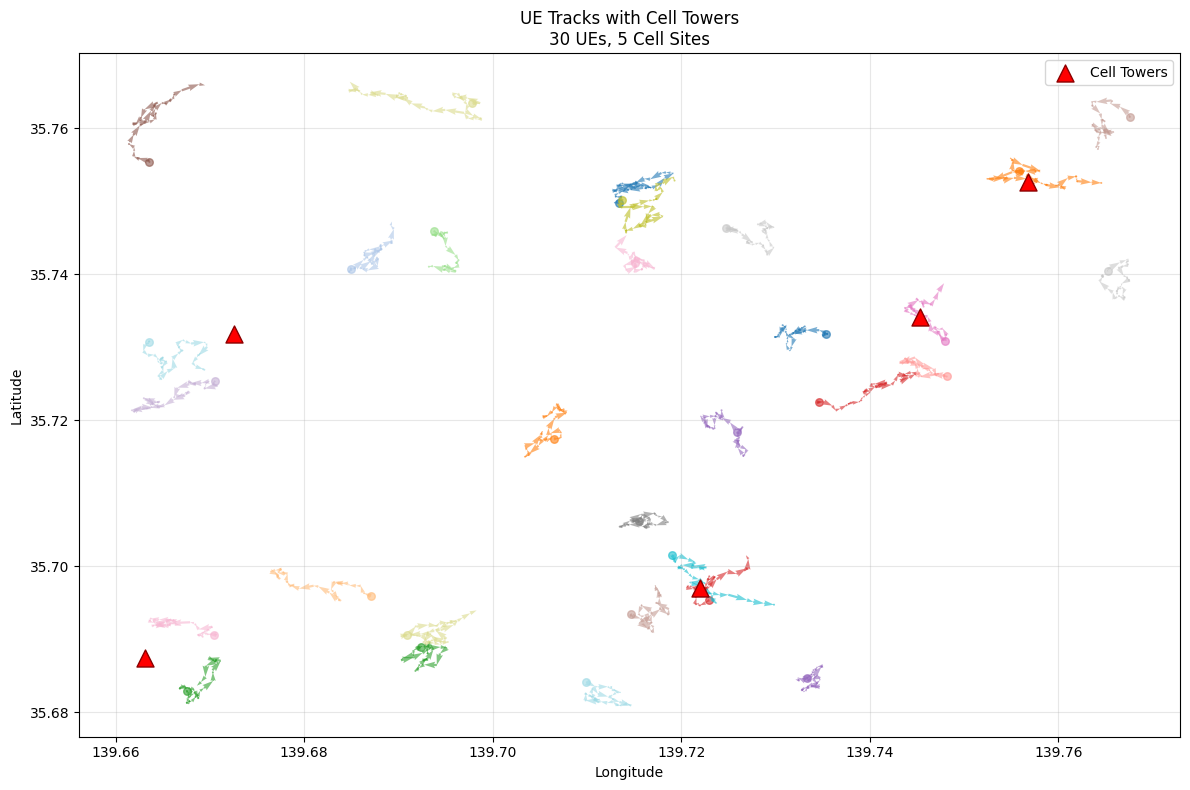

Saved visualization to: data/agentic_data/mobility/ue_tracks_with_topology.png


In [12]:
# Plot UE tracks with cell towers using the dedicated function
print(f"Plotting UE tracks with {len(topology_df.groupby(['cell_lat', 'cell_lon']))} cell tower sites...")

plot_ue_tracks_with_topology(df, topology_df)

# Save
viz_path = output_dir / "ue_tracks_with_topology.png"
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved visualization to: {viz_path}")

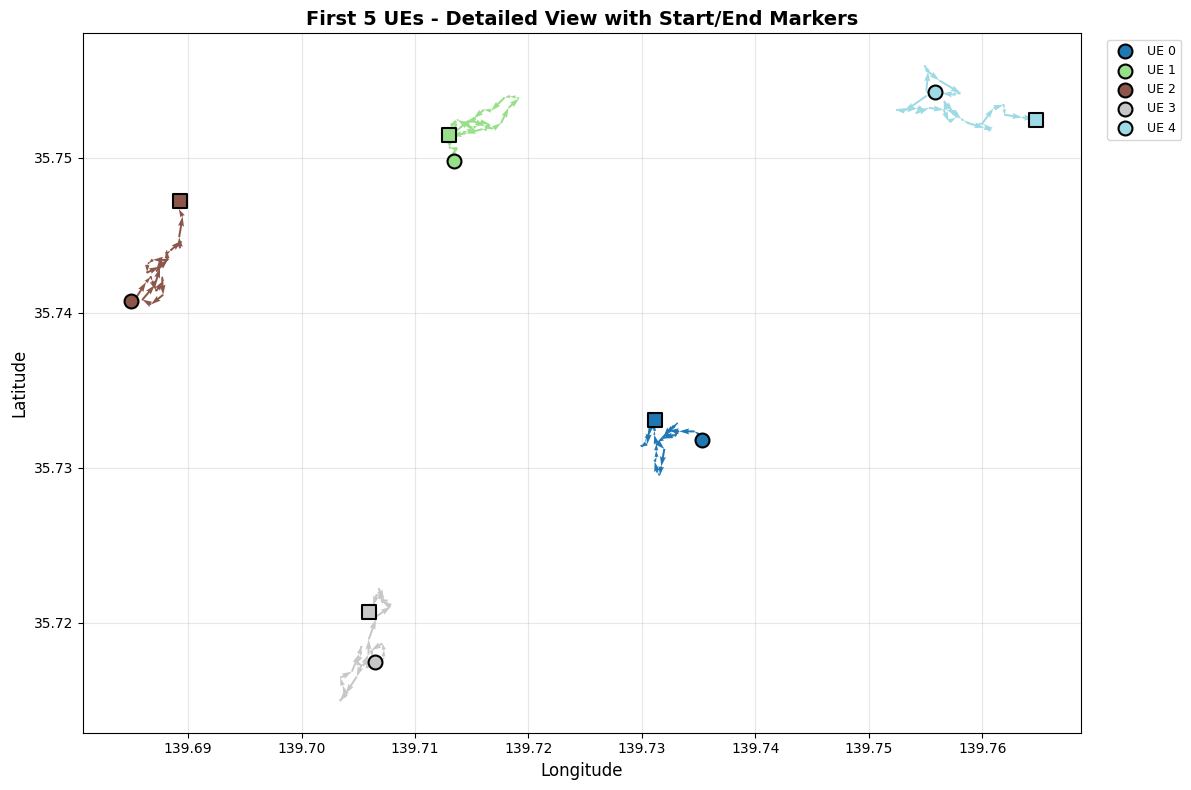

Saved visualization to: data/agentic_data/mobility/ue_tracks_subset.png


<Figure size 640x480 with 0 Axes>

In [13]:
# Plot first 5 UEs with legend
ue_ids_subset = sorted(df['mock_ue_id'].unique())[:5]

plot_ue_tracks(
    df, 
    legend=True, 
    ue_ids=ue_ids_subset,
    show_end_points=True,
    title="First 5 UEs - Detailed View with Start/End Markers"
)

# Save
viz_path = output_dir / "ue_tracks_subset.png"
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
print(f"Saved visualization to: {viz_path}")

---
## Part 5: Scenario Comparison

Generate a second scenario and compare side-by-side.

This demonstrates the flexibility of the agentic mobility system to handle different locations and scenarios.

---

In [14]:
# Generate a different scenario
query2 = "Generate 50 UEs in suburban Austin, Texas with lots of cars"

print(f"Query 2: '{query2}'")
print("Processing...\n")

df2, metadata2 = AgenticMobilityIntegration.generate_from_natural_language(query2)

print(f"Generated {len(df2)} mobility points for {metadata2['query_intent']['num_ues']} UEs")

# Display key differences
print("\nComparison:")
print(f"  Scenario 1: {metadata['query_intent']['location']} ({metadata['query_intent']['scenario_type']})")
print(f"  Scenario 2: {metadata2['query_intent']['location']} ({metadata2['query_intent']['scenario_type']})")
print(f"  UEs: {df['mock_ue_id'].nunique()} vs {df2['mock_ue_id'].nunique()}")

Query 2: 'Generate 50 UEs in suburban Austin, Texas with lots of cars'
Processing...

Generated 2500 mobility points for 50 UEs

Comparison:
  Scenario 1: Toshima, Tokyo, Japan (urban)
  Scenario 2: Austin, Texas (suburban)
  UEs: 30 vs 50


In [15]:
# Save scenario 2 data
csv_path2 = output_dir / "ue_tracks_scenario2.csv"
metadata_path2 = output_dir / "ue_tracks_scenario2_metadata.json"

df2.to_csv(csv_path2, index=False)
with open(metadata_path2, 'w') as f:
    json.dump(metadata2, f, indent=2)

print(f"Saved scenario 2 data to: {csv_path2}")
print(f"Saved scenario 2 metadata to: {metadata_path2}")

Saved scenario 2 data to: data/agentic_data/mobility/ue_tracks_scenario2.csv
Saved scenario 2 metadata to: data/agentic_data/mobility/ue_tracks_scenario2_metadata.json


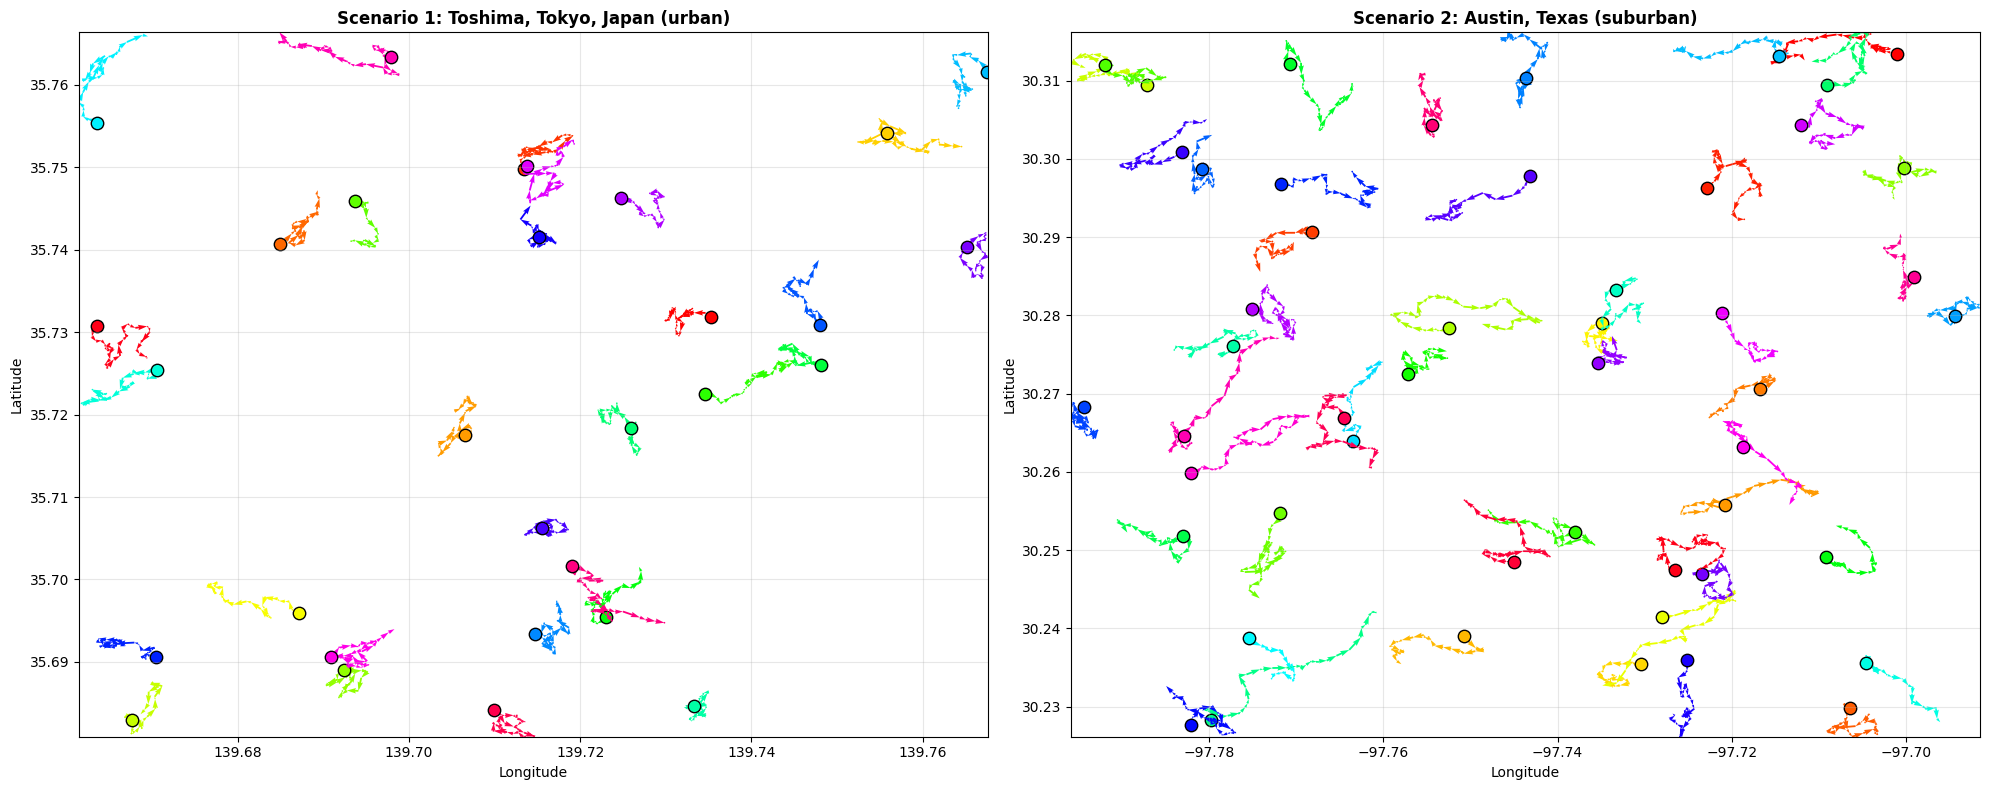

Saved comparison to: data/agentic_data/mobility/scenario_comparison.png


<Figure size 640x480 with 0 Axes>

In [16]:
# Side-by-side comparison
plot_ue_tracks_comparison(
    df, 
    df2,
    legend=False,
    titles=(
        f"Scenario 1: {metadata['query_intent']['location']} ({metadata['query_intent']['scenario_type']})",
        f"Scenario 2: {metadata2['query_intent']['location']} ({metadata2['query_intent']['scenario_type']})"
    )
)

# Save
viz_path = output_dir / "scenario_comparison.png"
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
print(f"Saved comparison to: {viz_path}")

---
## Part 6: Location Validation

Validate that the generated spatial bounds match the intended location using reverse geocoding.

The validation process:
1. Extracts 5 points: center + 4 corners (NW, NE, SW, SE)
2. Reverse geocodes each point using OpenStreetMap/Nominatim
3. Compares detected locations vs. query intent
4. Returns confidence scores and consistency metrics

**Note**: This makes 5 API calls with ~1 second rate limiting (~5 seconds total).

---

In [17]:
# Run location validation
if metadata and 'spatial_bounds' in metadata:
    print("Performing location validation...")
    print(f"Query location: {metadata.get('query_intent', {}).get('location')}")
    print("\n" + "="*70)
    
    validation_result = validate_location_bounds(metadata, threshold=0.7)
    
    print("\nValidation Results:")
    print("="*70)
    
    if validation_result['is_match']:
        print("LOCATION VALIDATED")
    else:
        print("LOCATION MISMATCH")
    
    print(f"\nOverall Confidence: {validation_result['overall_confidence']:.1%}")
    print(f"Consistency Score: {validation_result['consistency_score']:.1%}")
    print(f"Query Location: {validation_result['query_location']}")
    
    print("\nDetected Locations (5 points):")
    print("-"*70)
    for point_name, location in validation_result['detected_locations'].items():
        confidence = validation_result['point_confidences'][point_name]
        city = location.get('city', 'Unknown')
        country = location.get('country', 'Unknown')
        print(f"  {point_name.upper():8s}: {city}, {country} (confidence: {confidence:.1%})")
    
    if validation_result['warnings']:
        print("\nWarnings:")
        for warning in validation_result['warnings']:
            print(f"  - {warning}")
    
    print("\n" + "="*70)
else:
    print("No metadata or spatial_bounds available for validation")
    validation_result = None

Performing location validation...
Query location: Toshima, Tokyo, Japan

Reverse geocoding 5 points (center + 4 corners)...
This may take ~5 seconds due to rate limiting...

Validation Results:
LOCATION VALIDATED

Overall Confidence: 90.0%
Consistency Score: 70.0%
Query Location: Toshima, Tokyo, Japan

Detected Locations (5 points):
----------------------------------------------------------------------
  CENTER  : Toshima, Japan (confidence: 90.0%)
  NW      : Itabashi, Japan (confidence: 90.0%)
  NE      : Adachi, Japan (confidence: 90.0%)
  SW      : Nakano, Japan (confidence: 90.0%)
  SE      : Chuo, Japan (confidence: 90.0%)

Warnings:
  - Boundary spans multiple cities: Adachi, Toshima, Chuo, Nakano, Itabashi



---
## Part 7: Geographic World Map Visualization

Visualize the spatial bounds on an interactive world map.

Features:
- Red rectangle showing spatial bounds
- 5 validation points with markers (blue center, green corners)
- Legend with full addresses
- Auto-zoom based on coordinate span
- Hover for detailed info

---

In [18]:
# Create world map visualization
if metadata and 'spatial_bounds' in metadata and validation_result:
    print("Creating world map visualization...\n")
    
    fig_map = plot_bounds_on_map(
        validation_result,
        title="Spatial Bounds Validation - World Map View",
        figsize=(1200, 800)
    )
    
    fig_map.show()
    
    # Save to HTML
    map_path = output_dir / "bounds_world_map.html"
    fig_map.write_html(str(map_path))
    
    print(f"\nSaved interactive map to: {map_path}")
    print("\nInteractive Map Features:")
    print("   - Red rectangle shows the spatial bounds")
    print("   - Blue circle = Center point")
    print("   - Green diamonds = Corner points (NW, NE, SW, SE)")
    print("   - Hover over points to see full address details")
    print("   - Legend shows all 5 points with their geocoded addresses")
else:
    print("No validation result available for map visualization")

Creating world map visualization...




Saved interactive map to: data/agentic_data/mobility/bounds_world_map.html

Interactive Map Features:
   - Red rectangle shows the spatial bounds
   - Blue circle = Center point
   - Green diamonds = Corner points (NW, NE, SW, SE)
   - Hover over points to see full address details
   - Legend shows all 5 points with their geocoded addresses


---
## Part 8: Interactive Plotly Visualizations

Create interactive Plotly dashboards for exploring the mobility data.

Two visualization modes:
1. **UE-wise**: Dropdown menu to select and view individual UE tracks
2. **Tick-wise**: Slider to animate through time and see all UEs at each tick

Both are exportable to standalone HTML files.

---

In [19]:
# Create UE-wise interactive visualization
print("Creating UE-wise interactive visualization...\n")

ue_ids_subset = sorted(df['mock_ue_id'].unique())

fig_ue_wise = plot_ue_wise_interactive(
    df,
    ue_ids=ue_ids_subset,
    show_arrows=True,
    figsize=(1000, 700)
)

fig_ue_wise.show()

# Save to HTML
html_path = output_dir / "interactive_ue_wise.html"
fig_ue_wise.write_html(str(html_path))

print(f"Saved interactive UE-wise plot to: {html_path}")
print("\nFeatures:")
print("   - Use dropdown to switch between UEs")
print("   - Green circle = Start point")
print("   - Red square = End point")
print("   - Hover over points to see details (UE ID, tick, lat/lon)")

Creating UE-wise interactive visualization...



Saved interactive UE-wise plot to: data/agentic_data/mobility/interactive_ue_wise.html

Features:
   - Use dropdown to switch between UEs
   - Green circle = Start point
   - Red square = End point
   - Hover over points to see details (UE ID, tick, lat/lon)


In [20]:
# Create tick-wise interactive visualization
print("Creating tick-wise interactive visualization...\n")

fig_tick_wise = plot_tick_wise_interactive(
    df,
    initial_tick=0,
    color_by_ue=True,
    show_trails=False
)

fig_tick_wise.show()

# Save to HTML
html_path = output_dir / "interactive_tick_wise.html"
fig_tick_wise.write_html(str(html_path))

print(f"Saved interactive tick-wise plot to: {html_path}")
print("\nControls:")
print("   - Click PLAY button to animate through time")
print("   - Use slider to select specific tick")
print("   - Colors represent different UEs")
print("   - Hover to see UE ID, tick, and coordinates")

Creating tick-wise interactive visualization...



Saved interactive tick-wise plot to: data/agentic_data/mobility/interactive_tick_wise.html

Controls:
   - Click PLAY button to animate through time
   - Use slider to select specific tick
   - Colors represent different UEs
   - Hover to see UE ID, tick, and coordinates


---
## Part 9: Summary & Generated Files

Review all generated files and key metrics from this demonstration.

---

In [21]:
# List all generated files
print("="*70)
print("GENERATED FILES")
print("="*70)

all_files = sorted(output_dir.glob("*"))

for file_path in all_files:
    size_kb = file_path.stat().st_size / 1024
    print(f"{file_path.name:45s} {size_kb:>10.1f} KB")

print("\n" + "="*70)
print(f"Total files generated: {len(all_files)}")
print(f"Output directory: {output_dir.resolve()}")
print("="*70)

GENERATED FILES
bounds_world_map.html                             4555.1 KB
cell_topology.csv                                    0.2 KB
generation_params.json                               2.3 KB
interactive_tick_wise.html                        4627.3 KB
interactive_ue_wise.html                          4642.3 KB
scenario_comparison.png                              4.6 KB
ue_tracks.csv                                       62.1 KB
ue_tracks_metadata.json                              1.2 KB
ue_tracks_scenario2.csv                            105.0 KB
ue_tracks_scenario2_metadata.json                    1.0 KB
ue_tracks_subset.png                                 4.6 KB
ue_tracks_with_topology.png                        151.7 KB

Total files generated: 12
Output directory: /Users/azanzaman/Desktop/maveric1/notebooks/data/agentic_data/mobility


In [22]:
# Display summary metrics
print("\nSUMMARY METRICS")
print("="*70)
print(f"Query: '{query}'")
print(f"Location: {metadata['query_intent']['location']}")
print(f"Scenario: {metadata['query_intent']['scenario_type']}")
print(f"Total UEs: {df['mock_ue_id'].nunique()}")
print(f"Total Ticks: {df['tick'].max() + 1}")
print(f"Total Mobility Points: {len(df)}")
print(f"Cell Towers Generated: {len(unique_locations)} sites ({len(topology_df)} sectors)")

if validation_result:
    status = "PASSED" if validation_result['is_match'] else "FAILED"
    print(f"Location Validation: {status}")
    print(f"Validation Confidence: {validation_result['overall_confidence']:.1%}")

print("="*70)


SUMMARY METRICS
Query: 'Give me UE dataset for Toshima, Tokyo, Japan. consider it as a urban area with lots of pedestrians and cars. "
        There are so many motorbikes, consider them as cyclists. Have thirty total devices.
        Deploy 5 cell towers.'
Location: Toshima, Tokyo, Japan
Scenario: urban
Total UEs: 30
Total Ticks: 50
Total Mobility Points: 1500
Cell Towers Generated: 5 sites (5 sectors)
Location Validation: PASSED
Validation Confidence: 90.0%
